In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.special import gamma
from scipy.integrate import quad


# Acquisition et Visualisation des Données

## 1. Echantillon de loi de Weibull

In [104]:
# Paramètres choisis
beta = 3      # paramètre de forme
eta  = 4      # paramètre d'échelle (en milliers d'heures)
n    = 1000   # taille de l'échantillon

# Génération de l'échantillon
np.random.seed(42)
T = eta * np.random.weibull(beta, n)

E_theo = eta * gamma(1 + 1/beta)
V_theo = eta**2 * (gamma(1 + 2/beta) - gamma(1 + 1/beta)**2)

print(f"=== Vérification ===")
print(f"Moyenne empirique  : {T.mean():.4f}  |  Théorique : {E_theo:.4f}")
print(f"Écart-type empirique: {T.std():.4f}  |  Théorique : {V_theo**0.5:.4f}")

=== Vérification ===
Moyenne empirique  : 3.5290  |  Théorique : 3.5719
Écart-type empirique: 1.3002  |  Théorique : 1.2982


## 2. Histogramme des durées de vie

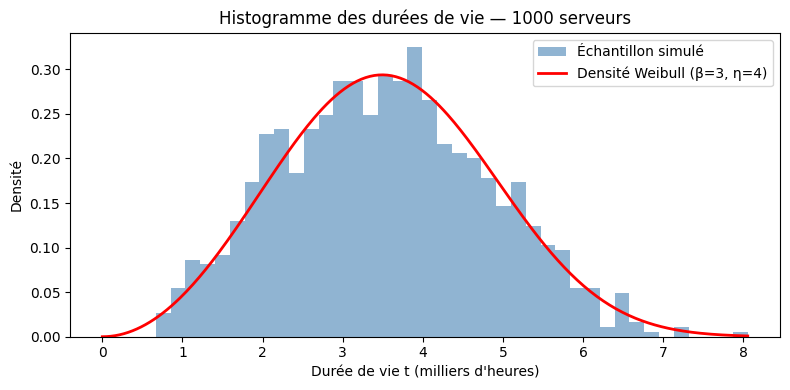

In [105]:
t_range = np.linspace(0, T.max(), 300)
f_theo  = (beta/eta) * (t_range/eta)**(beta-1) * np.exp(-(t_range/eta)**beta)

plt.figure(figsize=(8,4))
plt.hist(T, bins=40, density=True, alpha=0.6, color='steelblue', label='Échantillon simulé')
plt.plot(t_range, f_theo, 'r-', lw=2, label=f'Densité Weibull (β={beta}, η={eta})')
plt.xlabel('Durée de vie t (milliers d\'heures)')
plt.ylabel('Densité')
plt.title('Histogramme des durées de vie — 1000 serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('histogramme.png', dpi=150)
plt.show()

## 3. Fiabilité empirique R(t)


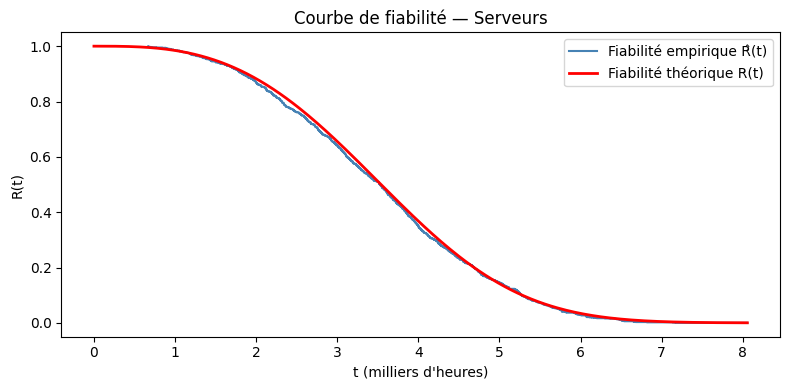

In [106]:
# ── Fiabilité empirique ──────────────────────────────────
T_sorted = np.sort(T)
R_emp    = 1 - np.arange(1, n+1) / n          # R̂(t) = nb vivants / nb total
R_theo   = np.exp(-(t_range/eta)**beta)        # R(t) théorique

plt.figure(figsize=(8,4))
plt.step(T_sorted, R_emp, color='steelblue', lw=1.5, label='Fiabilité empirique R̂(t)')
plt.plot(t_range, R_theo, 'r-', lw=2, label='Fiabilité théorique R(t)')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('R(t)')
plt.title('Courbe de fiabilité — Serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('fiabilite.png', dpi=150)
plt.show()

## 4. Taux de défaillance empirique λ(t)

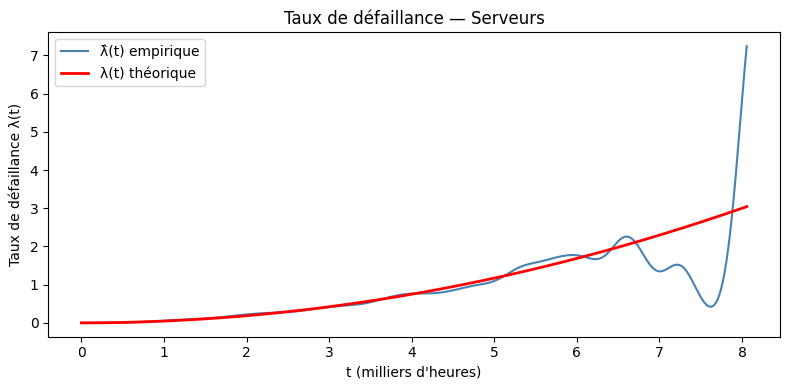

In [107]:
# ── Taux de défaillance empirique ────────────────────────
# f̂(t) via KDE, λ̂(t) = f̂(t) / R̂(t)

kde      = gaussian_kde(T, bw_method=0.15)
f_emp    = kde(t_range)
R_emp_c  = np.exp(-(t_range/eta)**beta)        # on utilise R théorique pour lisser
lambda_emp  = f_emp / R_emp_c
lambda_theo = (beta/eta) * (t_range/eta)**(beta-1)

plt.figure(figsize=(8,4))
plt.plot(t_range, lambda_emp,  color='steelblue', lw=1.5, label='λ̂(t) empirique')
plt.plot(t_range, lambda_theo, 'r-', lw=2,        label='λ(t) théorique')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('Taux de défaillance λ(t)')
plt.title('Taux de défaillance — Serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('taux_defaillance.png', dpi=150)
plt.show()

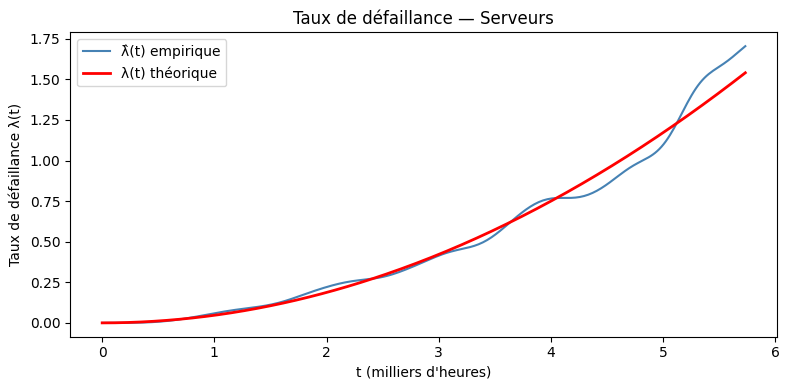

In [108]:
# ── Taux de défaillance empirique ────────────────────────
# f̂(t) via KDE, λ̂(t) = f̂(t) / R̂(t)

t_max_95 = np.percentile(T, 95)
t_range_95 = np.linspace(0, t_max_95, 300)

kde      = gaussian_kde(T, bw_method=0.15)
f_emp    = kde(t_range_95)
R_emp_c  = np.exp(-(t_range_95/eta)**beta)        # on utilise R théorique pour lisser
lambda_emp  = f_emp / R_emp_c
lambda_theo = (beta/eta) * (t_range_95/eta)**(beta-1)

plt.figure(figsize=(8,4))
plt.plot(t_range_95, lambda_emp,  color='steelblue', lw=1.5, label='λ̂(t) empirique')
plt.plot(t_range_95, lambda_theo, 'r-', lw=2,        label='λ(t) théorique')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('Taux de défaillance λ(t)')
plt.title('Taux de défaillance — Serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('taux_defaillance_corrigé.png', dpi=150)
plt.show()

# Estimation des Paramètres ("Papier de Weibull")

## 2. Estimation de β et η par régression linéaire

=== Estimation des paramètres ===
β réel : 3.000  |  β estimé : 3.012
η réel : 4.000  |  η estimé : 3.943


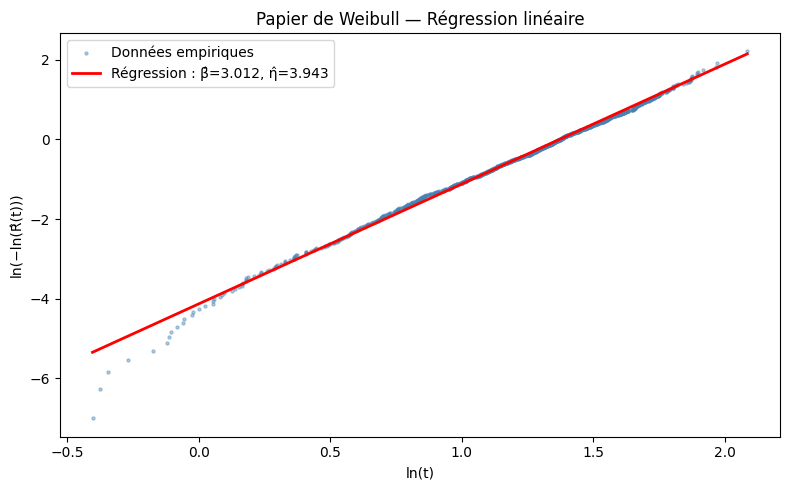

In [109]:
# ── Papier de Weibull ────────────────────────────────────
# On utilise la formule de Hazen pour éviter ln(0)
R_hazen = 1 - (np.arange(1, n+1) - 0.1) / n

# Transformation linéarisante
X = np.log(T_sorted)               # ln(t)
Y = np.log(-np.log(R_hazen))       # ln(-ln(R̂(t)))

# Régression linéaire
coeffs   = np.polyfit(X, Y, 1)
beta_est = coeffs[0]               # pente = β̂
eta_est  = np.exp(-coeffs[1] / beta_est)  # ordonnée → η̂

print(f"=== Estimation des paramètres ===")
print(f"β réel : {beta:.3f}  |  β estimé : {beta_est:.3f}")
print(f"η réel : {eta:.3f}  |  η estimé : {eta_est:.3f}")

# ── Tracé du Papier de Weibull ───────────────────────────
X_line = np.linspace(X.min(), X.max(), 200)
Y_line = beta_est * X_line - beta_est * np.log(eta_est)

plt.figure(figsize=(8,5))
plt.scatter(X, Y, s=5, alpha=0.4, color='steelblue', label='Données empiriques')
plt.plot(X_line, Y_line, 'r-', lw=2,
         label=f'Régression : β̂={beta_est:.3f}, η̂={eta_est:.3f}')
plt.xlabel('ln(t)')
plt.ylabel('ln(−ln(R̂(t)))')
plt.title('Papier de Weibull — Régression linéaire')
plt.legend()
plt.tight_layout()
plt.savefig('papier_weibull.png', dpi=150)
plt.show()

# Optimisation de l'architecture

## 1. Echantillons de loi exponentielle

In [110]:
# ── Paramètres des composants ────────────────────────────
mu1 = 1/2.0   # composant 1 : durée moyenne = 2000h
mu2 = 1/3.0   # composant 2 : durée moyenne = 3000h
N   = 10000
np.random.seed(42)

# Simulation lois exponentielles
T1 = np.random.exponential(scale=1/mu1, size=N)
T2 = np.random.exponential(scale=1/mu2, size=N)

print(f"Moyenne T1 : {T1.mean():.4f}  |  Théorique : {1/mu1:.4f}")
print(f"Moyenne T2 : {T2.mean():.4f}  |  Théorique : {1/mu2:.4f}")

Moyenne T1 : 1.9550  |  Théorique : 2.0000
Moyenne T2 : 3.0556  |  Théorique : 3.0000


## 2. Durée de vie de système en série

In [111]:
# ── Série : le système meurt si L'UN tombe ───────────────
T_serie = np.minimum(T1, T2)

E_serie_emp  = T_serie.mean()
E_serie_theo = 1 / (mu1 + mu2)

print(f"\n=== Série ===")
print(f"Moyenne empirique  : {E_serie_emp:.4f}")
print(f"Moyenne théorique  : {E_serie_theo:.4f}")


=== Série ===
Moyenne empirique  : 1.1919
Moyenne théorique  : 1.2000


## 3. Durée de vie de système en parallèle

In [112]:
# ── Parallèle : le système meurt si LES DEUX tombent ─────
T_para = np.maximum(T1, T2)

E_para_emp  = T_para.mean()
E_para_theo = 1/mu1 + 1/mu2 - 1/(mu1+mu2)

print(f"\n=== Parallèle ===")
print(f"Moyenne empirique  : {E_para_emp:.4f}")
print(f"Moyenne théorique  : {E_para_theo:.4f}")


=== Parallèle ===
Moyenne empirique  : 3.8187
Moyenne théorique  : 3.8000


## 4. Comparaison


Montage         Empirique    Théorique
---------------------------------------------
Série              1.1919       1.2000
Parallèle          3.8187       3.8000
Gain x               3.20         3.17


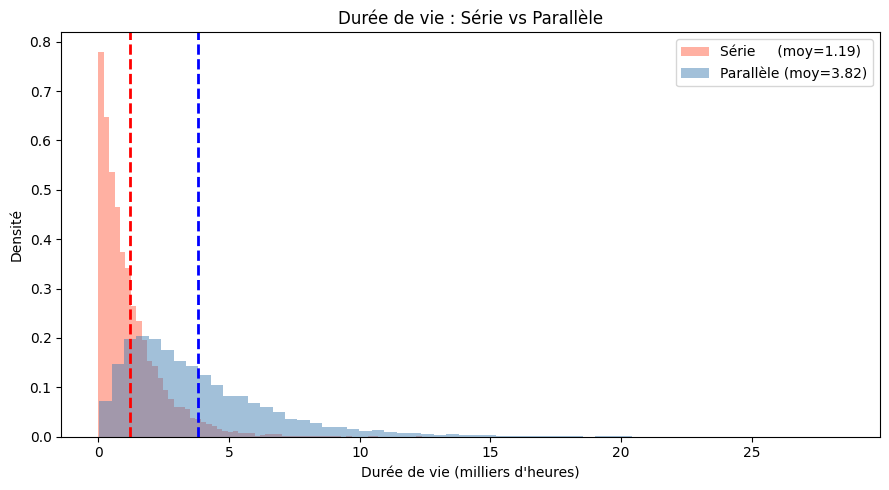

In [113]:
# ── Tableau comparatif ───────────────────────────────────
print(f"\n{'='*45}")
print(f"{'Montage':<12} {'Empirique':>12} {'Théorique':>12}")
print(f"{'-'*45}")
print(f"{'Série':<12} {E_serie_emp:>12.4f} {E_serie_theo:>12.4f}")
print(f"{'Parallèle':<12} {E_para_emp:>12.4f} {E_para_theo:>12.4f}")
print(f"{'Gain x':<12} {E_para_emp/E_serie_emp:>12.2f} {E_para_theo/E_serie_theo:>12.2f}")
print(f"{'='*45}")

# ── Histogramme comparatif ───────────────────────────────
plt.figure(figsize=(9,5))
plt.hist(T_serie, bins=60, density=True, alpha=0.5,
         color='tomato',     label=f'Série     (moy={E_serie_emp:.2f})')
plt.hist(T_para,  bins=60, density=True, alpha=0.5,
         color='steelblue',  label=f'Parallèle (moy={E_para_emp:.2f})')
plt.axvline(E_serie_emp, color='red',      lw=2, linestyle='--')
plt.axvline(E_para_emp,  color='blue',     lw=2, linestyle='--')
plt.xlabel('Durée de vie (milliers d\'heures)')
plt.ylabel('Densité')
plt.title('Durée de vie : Série vs Parallèle')
plt.legend()
plt.tight_layout()
plt.savefig('serie_vs_parallele.png', dpi=150)
plt.show()

# Durée de Survie et Maintenance

## 1. Probabilité de survie

In [114]:
# ── Paramètres ───────────────────────────────────────────
t = 1.5    # déjà fonctionné 1500h
x = 0.5    # 500h supplémentaires

# Fiabilité de Weibull
def R(t):
    return np.exp(-(t/eta)**beta)

# Probabilité de survie conditionnelle
prob = R(t + x) / R(t)

print(f"=== Survie conditionnelle ===")
print(f"R(t)       = R({t})   = {R(t):.6f}")
print(f"R(t+x)     = R({t+x}) = {R(t+x):.6f}")
print(f"P(T > {t+x} | T > {t}) = {prob:.6f}")
print(f"Soit environ {prob*100:.2f}% de chance de survivre 500h de plus")

=== Survie conditionnelle ===
R(t)       = R(1.5)   = 0.948632
R(t+x)     = R(2.0) = 0.882497
P(T > 2.0 | T > 1.5) = 0.930284
Soit environ 93.03% de chance de survivre 500h de plus


## 2. Temps moyen

In [115]:
# ── Intégration numérique ────────────────────────────────
integrale, erreur = quad(R, t, np.inf)
E_residuelle = integrale / R(t)

print(f"\n=== Espérance de vie résiduelle ===")
print(f"Intégrale de R(u) de {t} à +∞ : {integrale:.6f}")
print(f"R({t})                          : {R(t):.6f}")
print(f"E[T_t]                          : {E_residuelle:.4f} milliers d'heures")
print(f"Soit environ {E_residuelle*1000:.1f} heures restantes en moyenne")


=== Espérance de vie résiduelle ===
Intégrale de R(u) de 1.5 à +∞ : 2.091399
R(1.5)                          : 0.948632
E[T_t]                          : 2.2046 milliers d'heures
Soit environ 2204.6 heures restantes en moyenne


## 3. Moment de remplacement


=== Décision de maintenance ===
Seuil critique λ* = C_rem/C_panne = 0.100
t* (remplacement recommandé)       = 1.4615 milliers d'heures
Soit environ 1462 heures de fonctionnement


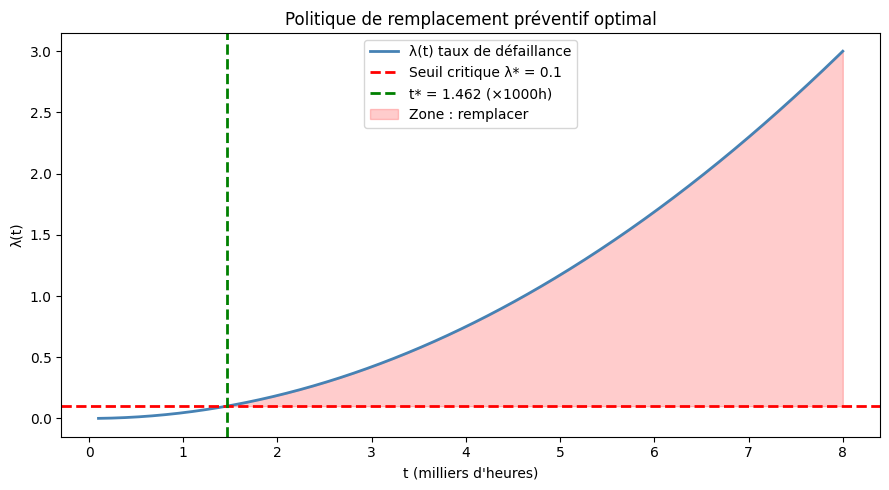

In [116]:
# ── Analyse coût-bénéfice ────────────────────────────────
cout_panne       = 10   # unités relatives
cout_remplacement = 1

# Pour chaque instant t, coût espéré si on attend vs si on remplace
t_vals = np.linspace(0.1, 8, 500)

# Taux de défaillance λ(t) = coût instantané du risque
lambda_vals = (beta/eta) * (t_vals/eta)**(beta-1)

# Seuil critique : λ(t*) = cout_remplacement / cout_panne
lambda_seuil = cout_remplacement / cout_panne  # = 0.1

# Trouver t* où λ(t) dépasse le seuil
idx_star = np.argmax(lambda_vals >= lambda_seuil)
t_star   = t_vals[idx_star]

print(f"\n=== Décision de maintenance ===")
print(f"Seuil critique λ* = C_rem/C_panne = {lambda_seuil:.3f}")
print(f"t* (remplacement recommandé)       = {t_star:.4f} milliers d'heures")
print(f"Soit environ {t_star*1000:.0f} heures de fonctionnement")

# ── Visualisation ────────────────────────────────────────
plt.figure(figsize=(9,5))
plt.plot(t_vals, lambda_vals, 'steelblue', lw=2, label='λ(t) taux de défaillance')
plt.axhline(lambda_seuil, color='red', lw=2, linestyle='--',
            label=f'Seuil critique λ* = {lambda_seuil}')
plt.axvline(t_star, color='green', lw=2, linestyle='--',
            label=f't* = {t_star:.3f} (×1000h)')
plt.fill_between(t_vals, lambda_vals, lambda_seuil,
                 where=(lambda_vals >= lambda_seuil),
                 alpha=0.2, color='red', label='Zone : remplacer')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('λ(t)')
plt.title('Politique de remplacement préventif optimal')
plt.legend()
plt.tight_layout()
plt.savefig('maintenance.png', dpi=150)
plt.show()

# Processus du renouvelement

## 1. Simulation du processus

In [118]:
# ── Paramètres ───────────────────────────────────────────
n_sim  = 1000        # nombre de serveurs simulés
T_max  = 20.0       # horizon temporel (20 000h)

In [119]:
# ── Simulation d'un processus de renouvellement ──────────
def simuler_renouvellement(beta, eta, T_max):
    """
    Simule les instants de pannes successives jusqu'à T_max.
    Retourne la liste des instants de panne.
    """
    pannes = []
    t = 0
    while t < T_max:
        # Nouvelle durée de vie tirée selon Weibull
        duree = eta * np.random.weibull(beta)
        t += duree
        if t < T_max:
            pannes.append(t)
    return np.array(pannes)

In [120]:
# Simuler les serveurs
tous_renouvellements = [
    simuler_renouvellement(beta, eta, T_max)
    for _ in range(n_sim)
]

In [121]:
# Afficher quelques statistiques
n_pannes = [len(r) for r in tous_renouvellements]
print(f"=== Statistiques sur {T_max*1000:.0f}h ===")
print(f"Nombre moyen de pannes : {np.mean(n_pannes):.2f}")
print(f"Min / Max              : {np.min(n_pannes)} / {np.max(n_pannes)}")

=== Statistiques sur 20000h ===
Nombre moyen de pannes : 5.11
Min / Max              : 3 / 8


## 2. Fonction de renouvelement M(t)

In [122]:
# ── Calcul de M(t) = E[N(t)] empirique ──────────────────
t_grid = np.linspace(0, T_max, 300)

def N_t(renouvellements, t):
    """Nombre de pannes jusqu'à l'instant t"""
    return np.sum(renouvellements <= t)

# Pour chaque instant t, moyenne sur tous les serveurs
M_emp = np.array([
    np.mean([N_t(r, t) for r in tous_renouvellements])
    for t in t_grid
])

In [123]:
# ── Approximation théorique M(t) ≈ t / E[T] ─────────────
E_T      = eta * gamma(1 + 1/beta)    # espérance théorique Weibull
M_theo   = t_grid / E_T              # approximation asymptotique

print(f"\nEspérance de vie théorique E[T] = {E_T:.4f} milliers d'heures")
print(f"Taux asymptotique de pannes     = {1/E_T:.4f} pannes / millier d'heures")


Espérance de vie théorique E[T] = 3.5719 milliers d'heures
Taux asymptotique de pannes     = 0.2800 pannes / millier d'heures


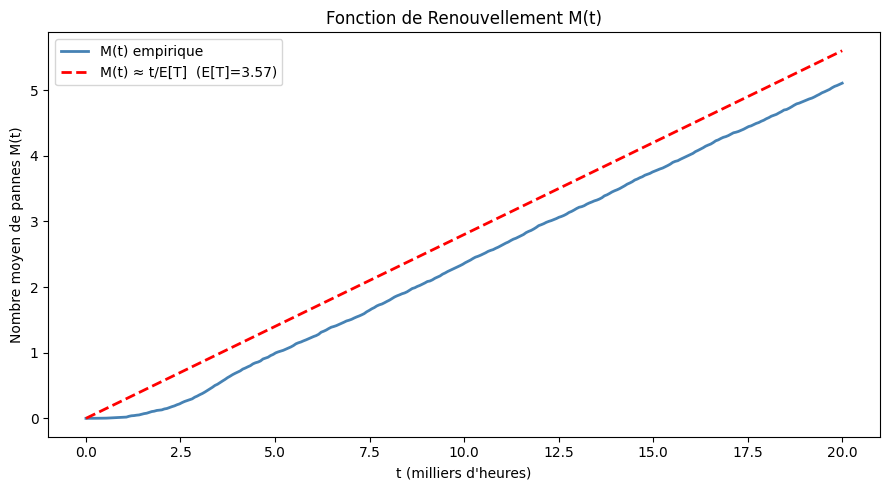

In [124]:
# ── Tracé ────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(t_grid, M_emp,   color='steelblue', lw=2,
         label='M(t) empirique')
plt.plot(t_grid, M_theo,  color='red',       lw=2,
         linestyle='--',  label=f'M(t) ≈ t/E[T]  (E[T]={E_T:.2f})')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('Nombre moyen de pannes M(t)')
plt.title('Fonction de Renouvellement M(t)')
plt.legend()
plt.tight_layout()
plt.savefig('renouvellement_Mt.png', dpi=150)
plt.show()

## 3. Trajectoires individuelles

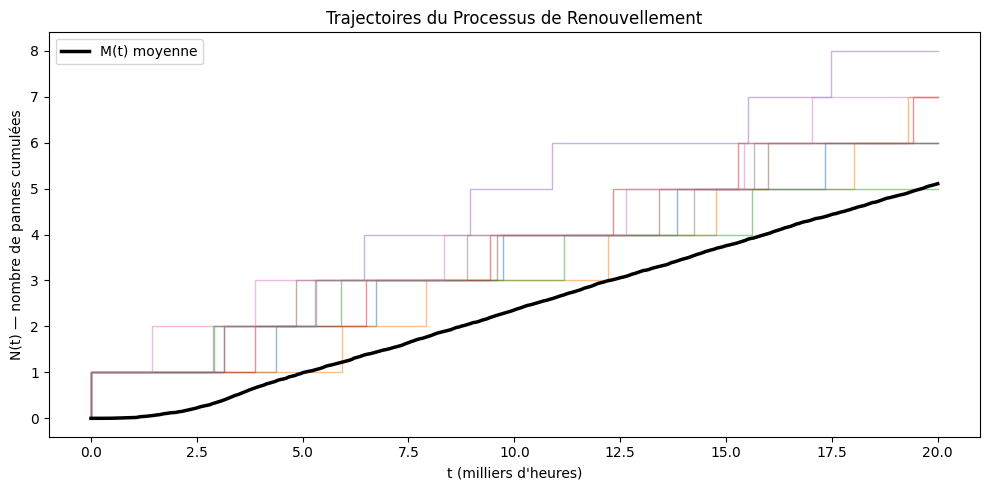

In [125]:
# ── Visualisation de quelques trajectoires ───────────────
plt.figure(figsize=(10, 5))

for i in range(8):    # 8 serveurs exemple
    pannes = tous_renouvellements[i]
    # Construire la courbe N(t) en escalier
    t_traj = np.concatenate([[0], pannes, [T_max]])
    N_traj = np.arange(len(t_traj))
    plt.step(t_traj, N_traj, alpha=0.5, lw=1)

# Moyenne
plt.plot(t_grid, M_emp, 'k-', lw=2.5, label='M(t) moyenne')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('N(t) — nombre de pannes cumulées')
plt.title('Trajectoires du Processus de Renouvellement')
plt.legend()
plt.tight_layout()
plt.savefig('renouvellement_trajectoires.png', dpi=150)
plt.show()

## 4. Analyse des coûts de maintenance


=== Analyse des coûts sur 20000h ===
Coût moyen total   : 52.05 unités
Écart-type         : 9.04 unités
Coût par 1000h     : 2.60 unités


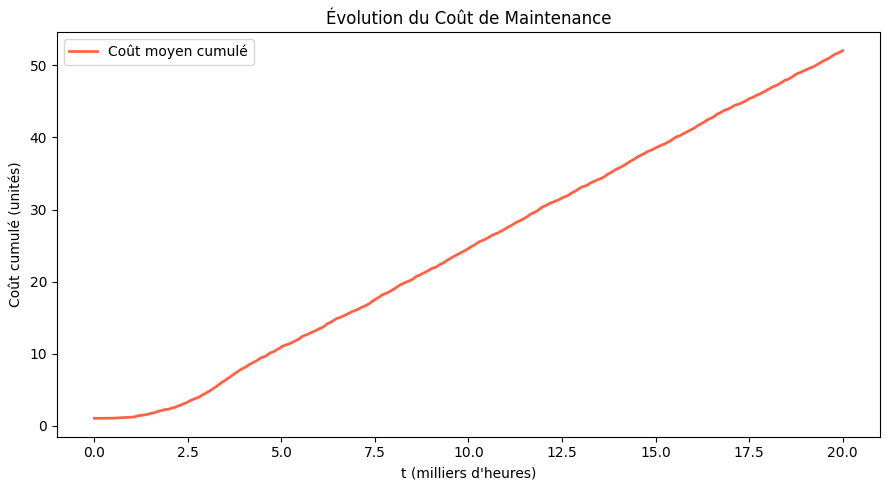

In [126]:
# ── Modèle de coût ───────────────────────────────────────
cout_panne        = 10   # coût panne imprévue
cout_remplacement = 1    # coût remplacement préventif

# Coût total sur [0, T_max] pour chaque serveur
couts = [
    len(r) * cout_panne + cout_remplacement
    for r in tous_renouvellements
]

cout_moyen = np.mean(couts)
cout_std   = np.std(couts)

print(f"\n=== Analyse des coûts sur {T_max*1000:.0f}h ===")
print(f"Coût moyen total   : {cout_moyen:.2f} unités")
print(f"Écart-type         : {cout_std:.2f} unités")
print(f"Coût par 1000h     : {cout_moyen/T_max:.2f} unités")

# ── Évolution du coût moyen cumulé dans le temps ─────────
cout_par_t = M_emp * cout_panne + cout_remplacement

plt.figure(figsize=(9, 5))
plt.plot(t_grid, cout_par_t, color='tomato', lw=2,
         label='Coût moyen cumulé')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('Coût cumulé (unités)')
plt.title('Évolution du Coût de Maintenance')
plt.legend()
plt.tight_layout()
plt.savefig('renouvellement_cout.png', dpi=150)
plt.show()

# Test de Kolmogorov-Smirnov

## 1. Transformation des données Weibull en Exponentielle

In [127]:
# ── Astuce mathématique ──────────────────────────────────
# Si T ~ Weibull(β, η) alors Z = (T/η)^β ~ Exponentielle(1)
# On peut donc tester Z ~ Exp(1) ce qui est plus simple

Z = (T / eta) ** beta    # transformation

print("=== Vérification de la transformation ===")
print(f"Moyenne de Z  : {Z.mean():.4f}  (théorique : 1.000)")
print(f"Variance de Z : {Z.var():.4f}  (théorique : 1.000)")

=== Vérification de la transformation ===
Moyenne de Z  : 0.9725  (théorique : 1.000)
Variance de Z : 0.9448  (théorique : 1.000)


## 2. Test KS sur les données transformées

In [128]:
# ── Test KS : Z suit-elle une Exp(1) ? ───────────────────
stat_ks, p_value = stats.kstest(Z, 'expon')

print(f"\n=== Test de Kolmogorov-Smirnov ===")
print(f"Statistique Dn  : {stat_ks:.6f}")
print(f"p-value         : {p_value:.6f}")
print()
if p_value > 0.05:
    print("✅ p-value > 0.05 → On ne rejette pas le modèle Weibull")
    print("   Les données sont compatibles avec une loi de Weibull(β, η)")
else:
    print("❌ p-value < 0.05 → On rejette le modèle Weibull")
    print("   Les données ne suivent pas une loi de Weibull(β, η)")


=== Test de Kolmogorov-Smirnov ===
Statistique Dn  : 0.029956
p-value         : 0.324375

✅ p-value > 0.05 → On ne rejette pas le modèle Weibull
   Les données sont compatibles avec une loi de Weibull(β, η)


## 3. Test KS directement sur T

In [129]:
# ── Test KS direct sur T ~ Weibull(β, η) ─────────────────
# scipy utilise la paramétrisation Weibull différente
# Weibull(β, η) → kstest avec cdf personnalisée

def cdf_weibull(t):
    return 1 - np.exp(-(t / eta) ** beta)

stat_ks2, p_value2 = stats.kstest(T, cdf_weibull)

print(f"\n=== Test KS direct sur T ===")
print(f"Statistique Dn  : {stat_ks2:.6f}")
print(f"p-value         : {p_value2:.6f}")
if p_value2 > 0.05:
    print("✅ Modèle Weibull validé statistiquement")
else:
    print("❌ Modèle Weibull rejeté")


=== Test KS direct sur T ===
Statistique Dn  : 0.029956
p-value         : 0.324375
✅ Modèle Weibull validé statistiquement


## 4. Visualisation de l'écart Dn

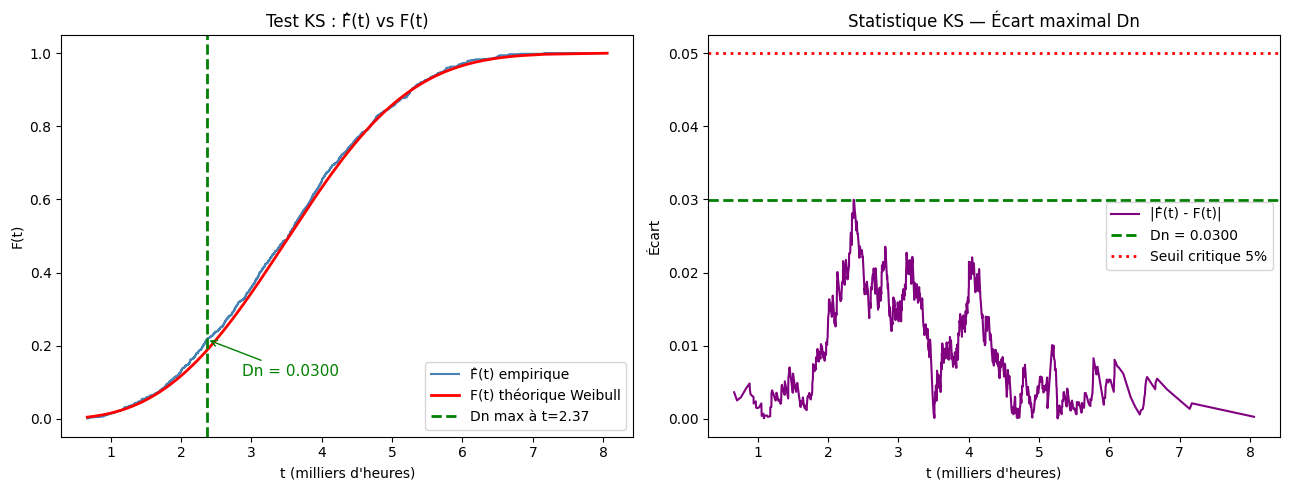

In [130]:
# ── Calcul manuel de Dn pour visualisation ───────────────
T_sorted  = np.sort(T)
n         = len(T_sorted)
F_emp     = np.arange(1, n+1) / n               # F̂(t) empirique
F_theo    = 1 - np.exp(-(T_sorted/eta)**beta)   # F(t) théorique

# Écart point par point
ecarts    = np.abs(F_emp - F_theo)
idx_max   = np.argmax(ecarts)
t_max_ks  = T_sorted[idx_max]
D_max     = ecarts[idx_max]

# ── Tracé ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Graphe 1 : F̂(t) vs F(t) ---
axes[0].step(T_sorted, F_emp,   color='steelblue', lw=1.5,
             label='F̂(t) empirique')
axes[0].plot(T_sorted, F_theo,  color='red',       lw=2,
             label='F(t) théorique Weibull')
axes[0].axvline(t_max_ks, color='green', lw=2, linestyle='--',
                label=f'Dn max à t={t_max_ks:.2f}')
axes[0].annotate(f'Dn = {D_max:.4f}',
                 xy=(t_max_ks, F_emp[idx_max]),
                 xytext=(t_max_ks + 0.5, F_emp[idx_max] - 0.1),
                 arrowprops=dict(arrowstyle='->', color='green'),
                 fontsize=11, color='green')
axes[0].set_xlabel('t (milliers d\'heures)')
axes[0].set_ylabel('F(t)')
axes[0].set_title('Test KS : F̂(t) vs F(t)')
axes[0].legend()

# --- Graphe 2 : Écart |F̂(t) - F(t)| ---
axes[1].plot(T_sorted, ecarts, color='purple', lw=1.5,
             label='|F̂(t) - F(t)|')
axes[1].axhline(D_max, color='green', lw=2, linestyle='--',
                label=f'Dn = {D_max:.4f}')
axes[1].axhline(0.05,  color='red',   lw=2, linestyle=':',
                label='Seuil critique 5%')
axes[1].set_xlabel('t (milliers d\'heures)')
axes[1].set_ylabel('Écart')
axes[1].set_title('Statistique KS — Écart maximal Dn')
axes[1].legend()

plt.tight_layout()
plt.savefig('test_ks.png', dpi=150)
plt.show()

## 5. Comparaison avec d'autres lois

In [131]:
# ── Est-ce que d'autres lois font mieux ? ────────────────
lois = {
    'Weibull'     : stats.kstest(T, cdf_weibull),
    'Exponentielle': stats.kstest(T, 'expon',
                      args=(0, 1/((beta/eta)*(1/eta)**(beta-1)))),
    'Normale'     : stats.kstest(T, 'norm',
                      args=(T.mean(), T.std())),
    'Log-normale' : stats.kstest(np.log(T), 'norm',
                      args=(np.log(T).mean(), np.log(T).std()))
}

print(f"\n{'='*50}")
print(f"{'Loi':<15} {'Dn':>10} {'p-value':>12} {'Verdict':>10}")
print(f"{'-'*50}")
for nom, (dn, pv) in lois.items():
    verdict = '✅' if pv > 0.05 else '❌'
    print(f"{nom:<15} {dn:>10.6f} {pv:>12.6f} {verdict:>10}")
print(f"{'='*50}")


Loi                     Dn      p-value    Verdict
--------------------------------------------------
Weibull           0.029956     0.324375          ✅
Exponentielle     0.730179     0.000000          ❌
Normale           0.031377     0.272712          ✅
Log-normale       0.079958     0.000005          ❌


# Test Chi-deux vs Scipy

In [132]:
# ── Découpage en k classes ───────────────────────────────
k = 20    # nombre de classes

# Bornes des classes : quantiles théoriques équiprobables
# (garantit Cᵢ = n/k ≥ 5 si n=1000 et k≤200)
probabilites = np.linspace(0, 1, k+1)
bornes = eta * (-np.log(1 - probabilites))**(1/beta)
bornes[0]  = 0
bornes[-1] = np.inf

print(f"=== Découpage en {k} classes équiprobables ===")
print(f"Effectif théorique par classe Cᵢ = {len(T)/k:.1f} ≥ 5 ✅")

=== Découpage en 20 classes équiprobables ===
Effectif théorique par classe Cᵢ = 50.0 ≥ 5 ✅


C:\Users\hajar\AppData\Local\Temp\ipykernel_33892\508447363.py:7: RuntimeWarning: divide by zero encountered in log
  bornes = eta * (-np.log(1 - probabilites))**(1/beta)


In [133]:
# ── Calcul des Oᵢ et Cᵢ ─────────────────────────────────
O = np.zeros(k)    # effectifs observés
C = np.zeros(k)    # effectifs théoriques

for i in range(k):
    borne_inf = bornes[i]
    borne_sup = bornes[i+1]

    # Oᵢ : nombre de données dans la classe i
    if i == k-1:
        O[i] = np.sum(T >= borne_inf)
    else:
        O[i] = np.sum((T >= borne_inf) & (T < borne_sup))

    # Cᵢ : effectif théorique = n × P(borne_inf ≤ T < borne_sup)
    p_inf = 1 - np.exp(-(borne_inf/eta)**beta) if borne_inf > 0 else 0
    p_sup = 1 - np.exp(-(borne_sup/eta)**beta) if borne_sup < np.inf else 1
    C[i]  = len(T) * (p_sup - p_inf)


In [134]:
# ── Statistique χ²_obs manuelle ─────────────────────────
chi2_manuel = np.sum((O - C)**2 / C)

# Degrés de liberté : ν = k - 1 - r
# r = 2 car on a estimé β et η
r  = 2
nu = k - 1 - r

# p-valeur manuelle : P(Y² ≥ χ²_obs) où Y² ~ χ²(ν)
p_value_manuel = 1 - stats.chi2.cdf(chi2_manuel, df=nu)

print(f"\n=== Test Chi-deux MANUEL (formule du cours) ===")
print(f"χ²_obs (manuel)   : {chi2_manuel:.6f}")
print(f"Degrés de liberté : ν = k-1-r = {k}-1-{r} = {nu}")
print(f"p-valeur (manuel) : {p_value_manuel:.6f}")


=== Test Chi-deux MANUEL (formule du cours) ===
χ²_obs (manuel)   : 14.880000
Degrés de liberté : ν = k-1-r = 20-1-2 = 17
p-valeur (manuel) : 0.604125


In [135]:
chi2_scipy, p_value_scipy = stats.chisquare(O, f_exp=C, ddof=r)

print(f"\n=== Test Chi-deux SCIPY ===")
print(f"χ²_obs (scipy)    : {chi2_scipy:.6f}")
print(f"p-valeur (scipy)  : {p_value_scipy:.6f}")


=== Test Chi-deux SCIPY ===
χ²_obs (scipy)    : 14.880000
p-valeur (scipy)  : 0.604125


In [136]:
alpha = 0.05
v_alpha = stats.chi2.ppf(1 - alpha, df=nu)   # valeur critique

print(f"\n{'='*55}")
print(f"{'':20} {'Manuel':>15} {'Scipy':>15}")
print(f"{'-'*55}")
print(f"{'χ²_obs':<20} {chi2_manuel:>15.6f} {chi2_scipy:>15.6f}")
print(f"{'p-valeur':<20} {p_value_manuel:>15.6f} {p_value_scipy:>15.6f}")
print(f"{'ν (ddl)':<20} {nu:>15d} {nu:>15d}")
print(f"{'v_α (seuil α=5%)':<20} {v_alpha:>15.6f} {v_alpha:>15.6f}")
print(f"{'='*55}")

# Décision selon le cours :
# Si χ²_obs ≥ v_α → on rejette H₀
# Si χ²_obs < v_α → on ne peut pas rejeter H₀
print(f"\n=== Décision (α = {alpha}) ===")
if chi2_manuel >= v_alpha:
    print(f"χ²_obs={chi2_manuel:.4f} ≥ v_α={v_alpha:.4f}")
    print("❌ On rejette H₀ : Weibull non validé")
else:
    print(f"χ²_obs={chi2_manuel:.4f} < v_α={v_alpha:.4f}")
    print("✅ On ne rejette pas H₀ : Weibull validé")

print(f"\n=== Décision via p-valeur (cours slide 3) ===")
if p_value_manuel <= alpha:
    print(f"p-valeur={p_value_manuel:.4f} ≤ α={alpha}")
    print("❌ Écart statistiquement significatif → on rejette H₀")
else:
    print(f"p-valeur={p_value_manuel:.4f} > α={alpha}")
    print("✅ Écart imputable au hasard → on ne rejette pas H₀")


                              Manuel           Scipy
-------------------------------------------------------
χ²_obs                     14.880000       14.880000
p-valeur                    0.604125        0.604125
ν (ddl)                           17              17
v_α (seuil α=5%)           27.587112       27.587112

=== Décision (α = 0.05) ===
χ²_obs=14.8800 < v_α=27.5871
✅ On ne rejette pas H₀ : Weibull validé

=== Décision via p-valeur (cours slide 3) ===
p-valeur=0.6041 > α=0.05
✅ Écart imputable au hasard → on ne rejette pas H₀


# Analyse de Sensibilité sur β et η

In [137]:
# ── Paramètres de référence ──────────────────────────────
beta_ref = 3
eta_ref  = 4.0
t_obs    = 1.5    # serveur ayant déjà survécu 1500h

## 1. Sensibilité sur β (forme)

In [138]:
# ── Grille de valeurs de β ───────────────────────────────
betas = np.linspace(1.0, 5.0, 100)

# Grandeurs à calculer
R_beta      = np.zeros(len(betas))   # fiabilité à t=1.5
ET_beta     = np.zeros(len(betas))   # espérance de vie
tstar_beta  = np.zeros(len(betas))   # temps optimal remplacement

t_grid = np.linspace(0.01, 15, 1000)

for idx, b in enumerate(betas):

    # Fiabilité R(t_obs)
    R_beta[idx] = np.exp(-(t_obs/eta_ref)**b)

    # Espérance E[T] = η × Γ(1 + 1/β)
    ET_beta[idx] = eta_ref * gamma(1 + 1/b)

    # t* : où λ(t) dépasse le seuil 0.1
    lambda_vals = (b/eta_ref) * (t_grid/eta_ref)**(b-1)
    idx_star    = np.argmax(lambda_vals >= 0.1)
    tstar_beta[idx] = t_grid[idx_star] if idx_star > 0 else np.nan



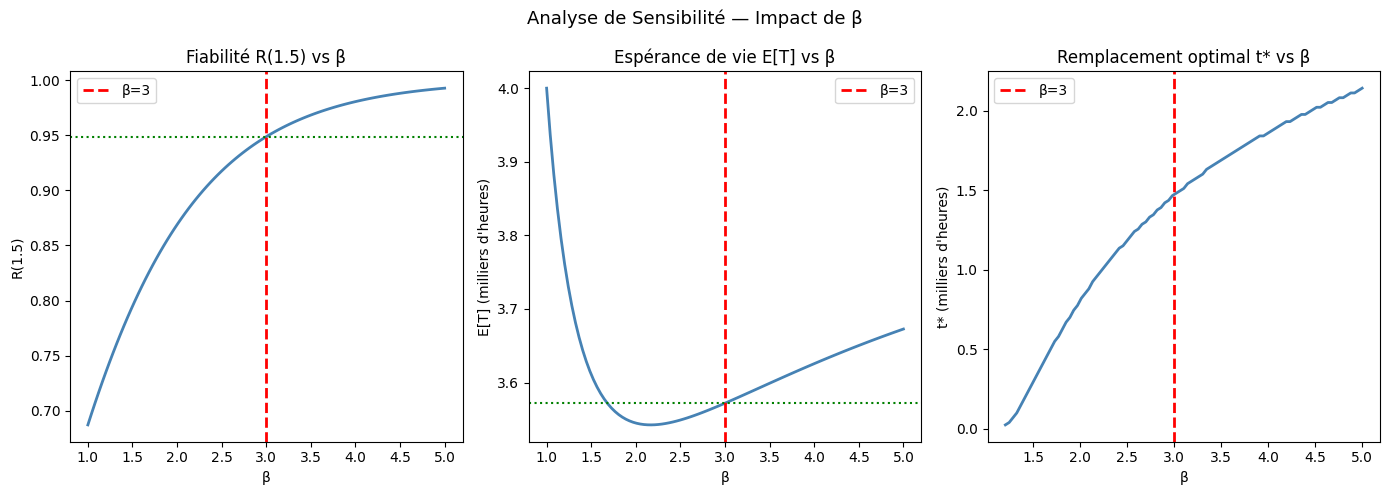

In [139]:
# ── Tracé ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Graphe 1 : R(t_obs) vs β
axes[0].plot(betas, R_beta, color='steelblue', lw=2)
axes[0].axvline(beta_ref, color='red', lw=2,
                linestyle='--', label=f'β={beta_ref}')
axes[0].axhline(np.exp(-(t_obs/eta_ref)**beta_ref),
                color='green', lw=1.5, linestyle=':')
axes[0].set_xlabel('β')
axes[0].set_ylabel(f'R({t_obs})')
axes[0].set_title(f'Fiabilité R({t_obs}) vs β')
axes[0].legend()

# Graphe 2 : E[T] vs β
axes[1].plot(betas, ET_beta, color='steelblue', lw=2)
axes[1].axvline(beta_ref, color='red', lw=2,
                linestyle='--', label=f'β={beta_ref}')
axes[1].axhline(eta_ref * gamma(1 + 1/beta_ref),
                color='green', lw=1.5, linestyle=':')
axes[1].set_xlabel('β')
axes[1].set_ylabel('E[T] (milliers d\'heures)')
axes[1].set_title('Espérance de vie E[T] vs β')
axes[1].legend()

# Graphe 3 : t* vs β
axes[2].plot(betas, tstar_beta, color='steelblue', lw=2)
axes[2].axvline(beta_ref, color='red', lw=2,
                linestyle='--', label=f'β={beta_ref}')
axes[2].set_xlabel('β')
axes[2].set_ylabel('t* (milliers d\'heures)')
axes[2].set_title('Remplacement optimal t* vs β')
axes[2].legend()

plt.suptitle('Analyse de Sensibilité — Impact de β', fontsize=13)
plt.tight_layout()
plt.savefig('sensibilite_beta.png', dpi=150)
plt.show()

## 2. Sensibilité sur η (échelle)

In [140]:
# ── Grille de valeurs de η ───────────────────────────────
etas = np.linspace(1.0, 8.0, 100)

R_eta     = np.zeros(len(etas))
ET_eta    = np.zeros(len(etas))
tstar_eta = np.zeros(len(etas))

for idx, e in enumerate(etas):

    # Fiabilité R(t_obs)
    R_eta[idx] = np.exp(-(t_obs/e)**beta_ref)

    # Espérance E[T]
    ET_eta[idx] = e * gamma(1 + 1/beta_ref)

    # t* optimal
    lambda_vals  = (beta_ref/e) * (t_grid/e)**(beta_ref-1)
    idx_star     = np.argmax(lambda_vals >= 0.1)
    tstar_eta[idx] = t_grid[idx_star] if idx_star > 0 else np.nan

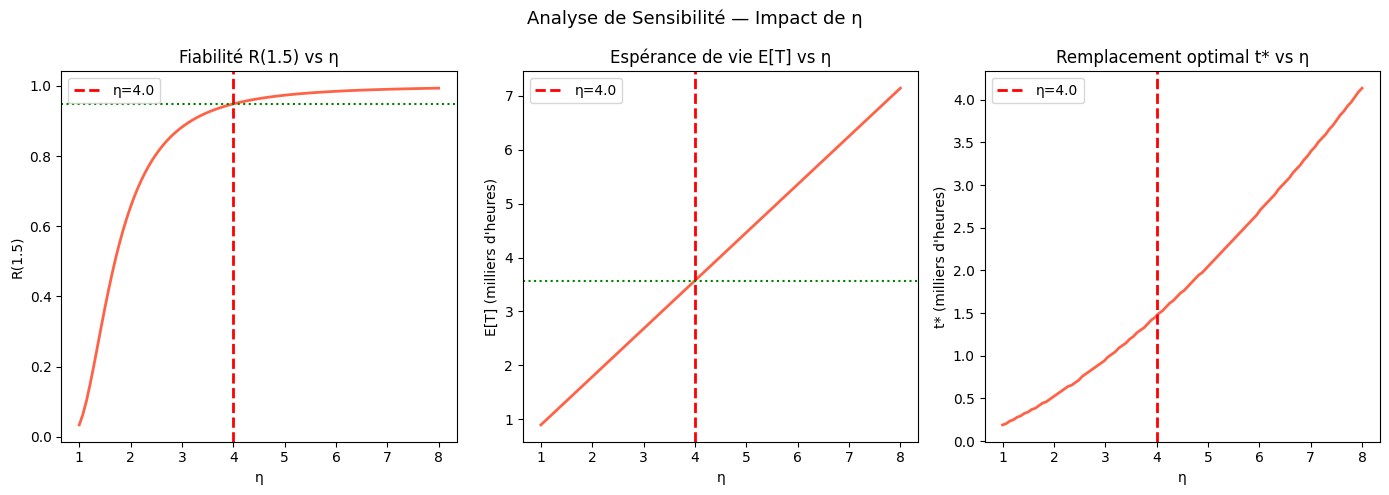

In [141]:
# ── Tracé ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].plot(etas, R_eta, color='tomato', lw=2)
axes[0].axvline(eta_ref, color='red', lw=2,
                linestyle='--', label=f'η={eta_ref}')
axes[0].axhline(np.exp(-(t_obs/eta_ref)**beta_ref),
                color='green', lw=1.5, linestyle=':')
axes[0].set_xlabel('η')
axes[0].set_ylabel(f'R({t_obs})')
axes[0].set_title(f'Fiabilité R({t_obs}) vs η')
axes[0].legend()

axes[1].plot(etas, ET_eta, color='tomato', lw=2)
axes[1].axvline(eta_ref, color='red', lw=2,
                linestyle='--', label=f'η={eta_ref}')
axes[1].axhline(eta_ref * gamma(1 + 1/beta_ref),
                color='green', lw=1.5, linestyle=':')
axes[1].set_xlabel('η')
axes[1].set_ylabel('E[T] (milliers d\'heures)')
axes[1].set_title('Espérance de vie E[T] vs η')
axes[1].legend()

axes[2].plot(etas, tstar_eta, color='tomato', lw=2)
axes[2].axvline(eta_ref, color='red', lw=2,
                linestyle='--', label=f'η={eta_ref}')
axes[2].set_xlabel('η')
axes[2].set_ylabel('t* (milliers d\'heures)')
axes[2].set_title('Remplacement optimal t* vs η')
axes[2].legend()

plt.suptitle('Analyse de Sensibilité — Impact de η', fontsize=13)
plt.tight_layout()
plt.savefig('sensibilite_eta.png', dpi=150)
plt.show()


## 3.Carte de chaleur (β, η) → E[T]

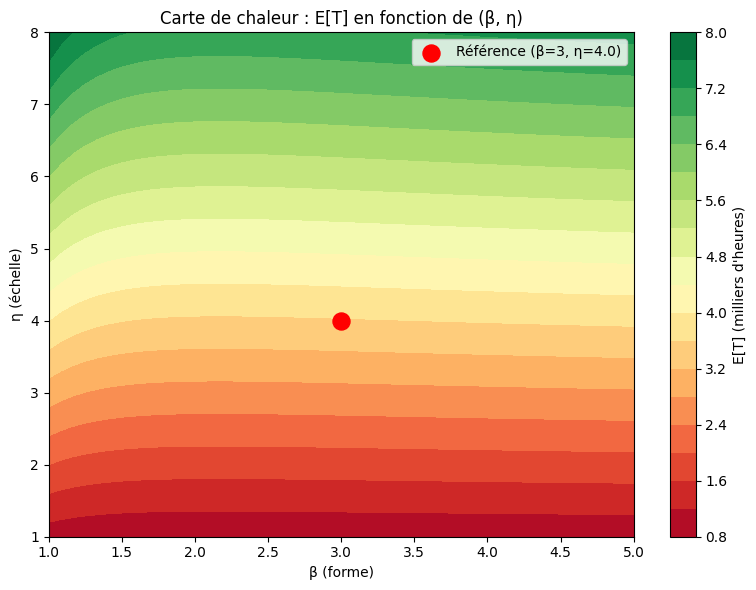

In [142]:
# ── Heatmap : impact conjoint de β et η sur E[T] ─────────
betas_grid = np.linspace(1.0, 5.0, 50)
etas_grid  = np.linspace(1.0, 8.0, 50)
BB, EE     = np.meshgrid(betas_grid, etas_grid)

ET_grid    = EE * gamma(1 + 1/BB)

plt.figure(figsize=(8, 6))
cp = plt.contourf(BB, EE, ET_grid, levels=20, cmap='RdYlGn')
plt.colorbar(cp, label='E[T] (milliers d\'heures)')
plt.scatter(beta_ref, eta_ref, color='red', s=150,
            zorder=5, label=f'Référence (β={beta_ref}, η={eta_ref})')
plt.xlabel('β (forme)')
plt.ylabel('η (échelle)')
plt.title('Carte de chaleur : E[T] en fonction de (β, η)')
plt.legend()
plt.tight_layout()
plt.savefig('heatmap_ET.png', dpi=150)
plt.show()

## 4. Indice de sensibilité (élasticité)

In [143]:
# ── Élasticité : variation relative de E[T] ──────────────
# S_β = (dE[T]/dβ) × (β/E[T])  → sensibilité normalisée

delta = 0.01   # perturbation de 1%

ET_ref     = eta_ref * gamma(1 + 1/beta_ref)

ET_beta_p  = eta_ref * gamma(1 + 1/(beta_ref*(1+delta)))
ET_eta_p   = eta_ref*(1+delta) * gamma(1 + 1/beta_ref)

S_beta = (ET_beta_p - ET_ref) / ET_ref / delta
S_eta  = (ET_eta_p  - ET_ref) / ET_ref / delta

print(f"=== Indices d'élasticité de E[T] ===")
print(f"Élasticité par rapport à β : {S_beta:+.4f}")
print(f"Élasticité par rapport à η : {S_eta:+.4f}")
print()
print(f"→ Une hausse de 1% de β modifie E[T] de {S_beta:+.2f}%")
print(f"→ Une hausse de 1% de η modifie E[T] de {S_eta:+.2f}%")
print()
if abs(S_eta) > abs(S_beta):
    print("✅ E[T] est plus sensible à η qu'à β")
    print("   → Bien estimer l'échelle η est prioritaire !")
else:
    print("✅ E[T] est plus sensible à β qu'à η")
    print("   → Bien estimer la forme β est prioritaire !")

=== Indices d'élasticité de E[T] ===
Élasticité par rapport à β : +0.0442
Élasticité par rapport à η : +1.0000

→ Une hausse de 1% de β modifie E[T] de +0.04%
→ Une hausse de 1% de η modifie E[T] de +1.00%

✅ E[T] est plus sensible à η qu'à β
   → Bien estimer l'échelle η est prioritaire !
